In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df = pd.read_csv("cleaned_MH_OC.csv")
print(df.shape)
df.head()

(29942, 161)


,lat_key,fid,latitude,longitude,CLIMATE_VALUE,CLIMATE_SUBCLASS,CLIMATE_CLASS,DOMSOI,SOIL_TYPE,SOIL_SUBCLASS,...,S1_VH_ASM,S1_VH_Energy,S1_VH_MaxProbability,S1_VH_Entropy,S1_VH_GLCM_Mean,S1_VH_GLCM_Variance,S1_VH_GLCM_Correlation,year,month,dayofyear
0,15.709677,48980.0,15.709677,74.047631,2.0,Am,Tropical,Ap,ACRISOLS,Plinthic Acrisols,...,0.699068,0.999988,0.995973,-4.731746,0.022191,0.000029,0.424396,2025,2,48
1,15.709731,48981.0,15.709731,74.048897,2.0,Am,Tropical,Ap,ACRISOLS,Plinthic Acrisols,...,0.636399,0.999990,0.997320,-4.856527,0.016932,0.000098,0.181971,2025,2,48
2,15.711065,48982.0,15.711065,74.047657,2.0,Am,Tropical,Ap,ACRISOLS,Plinthic Acrisols,...,0.606309,0.999960,0.995374,-4.144549,0.013338,0.000111,0.318890,2025,2,48
3,15.804995,48839.5,15.804995,73.733783,2.0,Am,Tropical,Nd,NITOSOLS,Dystric Nitosols,...,0.774612,0.999999,0.998807,-6.255501,0.007464,0.000004,0.314625,2024,3,91
4,15.805012,48835.0,15.805012,73.734112,2.0,Am,Tropical,Nd,NITOSOLS,Dystric Nitosols,...,0.648962,0.999997,0.998350,-5.404119,0.007534,0.000008,1.216725,2024,3,91


In [3]:
target = "OC_group_median"
sample_ids = df['fid']

drop_cols = ['fid',target]
X = df.drop(columns=drop_cols,errors='ignore')
y = df[target]

In [4]:
leakage_cols = [
    'OC',
    'OC_log1p',
    'OC_bin',
    'duplicate_OC_conflict_class'
]

remove_metadata = [
    'date',
    'tile_id',
    'tile_date',
    'source_csv',
    'source_s2_chunk',
    'bare_soil_reason',
    'S2_bare_soil_filter_reason',
    'spatial_qc_reason',
    'village',
    'lat_key'
]

remove_soil_props = [
    'N','P','K',
    'pH','EC',
    'S','Zn','Fe',
    'Mn','Cu','B',
    'DOMSOI',
    'SOIL_TYPE',
    'SOIL_SUBCLASS'
]

drop_terrain = [
'elev_mean_90m',
'elev_std_90m',
'elev_min_90m',
'elev_max_90m'
]

cols_to_remove = (
    leakage_cols +
    remove_metadata +
    remove_soil_props +
    drop_terrain
)

X = X.drop(
    columns=cols_to_remove,
    errors='ignore'
)

print(X.shape)

(29942, 128)


# Encoding categorical variables

In [5]:
cat_cols = X.select_dtypes(
    include='object'
).columns

print(cat_cols)

Index(['CLIMATE_SUBCLASS', 'CLIMATE_CLASS', 'state', 'district', 'period',
       'LULC_class', 'spatial_qc_status'],
      dtype='str')


/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_3707/1652557112.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(


In [6]:
for col in cat_cols:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(
        X[col].astype(str)
    )

In [7]:
bool_cols = X.select_dtypes(
    include='bool'
).columns

X[bool_cols] = X[
    bool_cols
].astype(int)

In [8]:
terrain_cols = [
'elevation','slope_deg',
'aspect_sin','aspect_cos',
'TWI','flow_acc',
'profile_curvature',
'plan_curvature',
'TPI_300m','TPI_600m',
'SPI','LS_factor'
]

climate_cols = [
'annual_rain_mm',
'R_factor',
'CLIMATE_CLASS',
'CLIMATE_SUBCLASS',
'CLIMATE_VALUE'
]

s2_cols = [
'B2','B3','B4','B5',
'B6','B7','B8',
'B8A','B11','B12',

'NDVI','BSI','NDWI',
'NDBI','SAVI',
'GNDVI','NDMI',
'MSI','NDTI_NBR2',
'MNDWI_Green_SWIR1'
]

s1_cols = [
'S1_VH',
'S1_VV',
'S1_VV_VH',

'S1_VV_Contrast',
'S1_VV_Entropy',

'S1_VH_Contrast',
'S1_VH_Entropy'
]

In [9]:
feature_sets = {

"Terrain":
terrain_cols,

"Terrain_Climate":
terrain_cols +
climate_cols,

"Terrain_Climate_S2":
terrain_cols +
climate_cols +
s2_cols,

"Terrain_Climate_S1_S2":
terrain_cols +
climate_cols +
s1_cols +
s2_cols
}

In [10]:
from sklearn.ensemble import RandomForestRegressor

results = {}

for name, cols in feature_sets.items():

    cols = [
        c for c in cols
        if c in X.columns
    ]

    X_exp = X[cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X_exp,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    results[name] = [
        len(cols),
        r2,
        rmse
    ]

In [11]:
results_df = pd.DataFrame(
    results,
    index=[
        "Features",
        "R2",
        "RMSE"
    ]
).T

print(
    results_df.sort_values(
        by="R2",
        ascending=False
    )
)

                       Features        R2      RMSE
Terrain_Climate            17.0  0.560351  0.289967
Terrain_Climate_S2         37.0  0.537515  0.297402
Terrain_Climate_S1_S2      44.0  0.534557  0.298351
Terrain                    12.0  0.421770  0.332541


- Satellite features are adding noise to the model
- We have to find a way to reduce the noise

# 1.Keep satellite data based on their feature importance

In [12]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [13]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(
    importance.head(30)
)

annual_rain_mm       0.207632
R_factor             0.194749
elevation            0.090129
TPI_600m             0.024391
TPI_300m             0.021442
NDTI_NBR2            0.021144
S1_VV                0.020424
S1_VV_VH             0.019048
S1_VH                0.018505
TWI                  0.018042
S1_VH_Entropy        0.017762
BSI                  0.016239
flow_acc             0.016050
NDVI                 0.015620
plan_curvature       0.015396
S1_VV_Entropy        0.015204
MNDWI_Green_SWIR1    0.014957
B2                   0.014930
S1_VV_Contrast       0.014250
profile_curvature    0.014122
B12                  0.013694
aspect_sin           0.013096
LS_factor            0.012459
B11                  0.012262
SAVI                 0.012240
aspect_cos           0.011832
SPI                  0.011455
S1_VH_Contrast       0.010786
B3                   0.010461
B5                   0.010298
dtype: float64


In [14]:
top_satellite = importance[
    importance.index.isin(
        s2_cols + s1_cols
    )
].head(10)

top_sat_cols = top_satellite.index.tolist()

print(top_sat_cols)

sat_importance = importance[
    importance.index.isin(
        s2_cols + s1_cols
    )
]

sat_importance = sat_importance.sort_values(
    ascending=False
)

print(
    sat_importance.head(20)
)

['NDTI_NBR2', 'S1_VV', 'S1_VV_VH', 'S1_VH', 'S1_VH_Entropy', 'BSI', 'NDVI', 'S1_VV_Entropy', 'MNDWI_Green_SWIR1', 'B2']
NDTI_NBR2            0.021144
S1_VV                0.020424
S1_VV_VH             0.019048
S1_VH                0.018505
S1_VH_Entropy        0.017762
BSI                  0.016239
NDVI                 0.015620
S1_VV_Entropy        0.015204
MNDWI_Green_SWIR1    0.014957
B2                   0.014930
S1_VV_Contrast       0.014250
B12                  0.013694
B11                  0.012262
SAVI                 0.012240
S1_VH_Contrast       0.010786
B3                   0.010461
B5                   0.010298
NDWI                 0.009874
GNDVI                0.009613
B4                   0.009612
dtype: float64


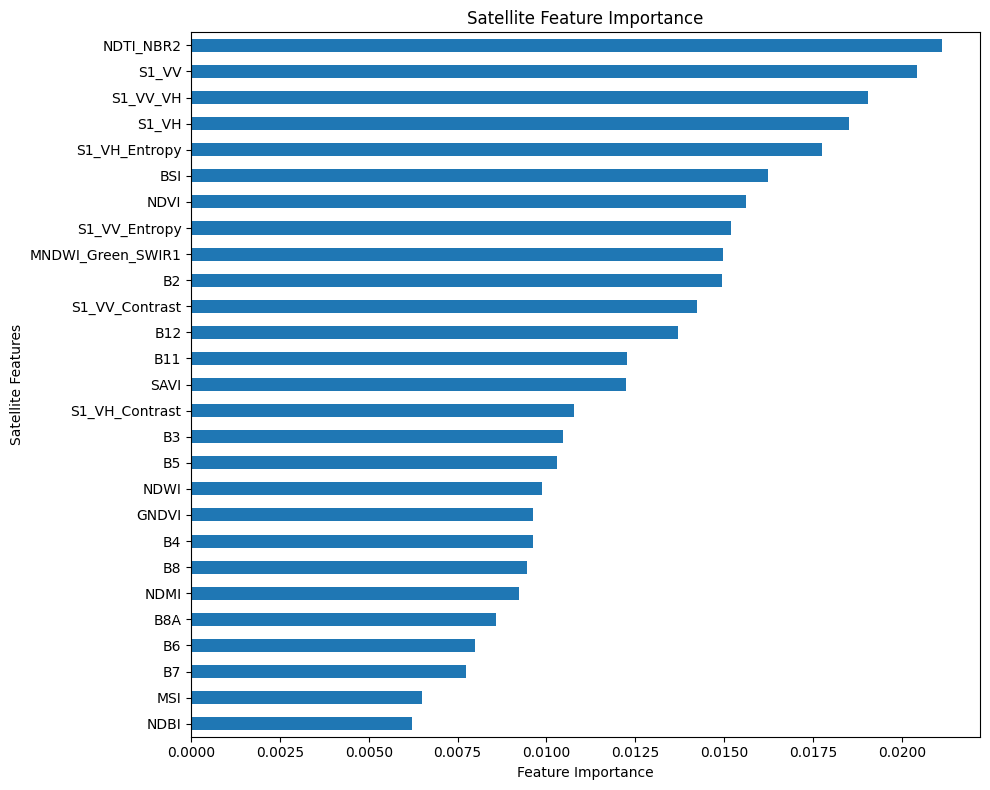

In [15]:
plt.figure(
    figsize=(10,8)
)

sat_importance.sort_values().plot(
    kind='barh'
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Satellite Features"
)

plt.title(
    "Satellite Feature Importance"
)

plt.tight_layout()

plt.show()

In [16]:
top_sat_cols = sat_importance.head(
    15
).index.tolist()
final_cols = (
    terrain_cols +
    climate_cols +
    top_sat_cols
)

In [17]:
final_cols = list(
    set(final_cols)
)

In [18]:
final_cols = [

    col for col in final_cols

    if col in X.columns
]

In [19]:
X_final = X[
    final_cols
]

print(
    X_final.shape
)

(29942, 32)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [22]:
pred = model.predict(
    X_test
)

print(
    "R2:",
    r2_score(
        y_test,
        pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )
)

R2: 0.5391940452508369
RMSE: 0.29686163839779467


# 2.Apply PCA on Satellite data

In [23]:
sat_cols = [

col for col in X.columns

if (
    
    col in s1_cols
    
    or
    
    col in s2_cols
)
]

print(
    len(sat_cols)
)

27


In [24]:
X_sat = X[
    sat_cols
]

X_other = X.drop(
    columns=sat_cols
)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_sat_scaled = scaler.fit_transform(
    X_sat
)

In [26]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95
)

X_sat_pca = pca.fit_transform(
    X_sat_scaled
)

print(
    X_sat.shape
)

print(
    X_sat_pca.shape
)

(29942, 27)
(29942, 10)


In [27]:
pca_cols = [

f"SAT_PC_{i}"

for i in range(
    X_sat_pca.shape[1]
)
]

X_sat_pca_df = pd.DataFrame(

    X_sat_pca,

    columns=pca_cols,

    index=X.index
)

In [28]:
X_final = pd.concat(

    [
        X_other,

        X_sat_pca_df
    ],

    axis=1
)

print(
    X_final.shape
)

(29942, 111)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(

    X_final,

    y,

    test_size=0.2,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

r2 = r2_score(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print(
    "R2:",
    r2
)

print(
    "RMSE:",
    rmse
)

R2: 0.5391940452508369
RMSE: 0.29686163839779467


# Feature importance

In [30]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(
    importance
)

annual_rain_mm                   0.168468
R_factor                         0.156229
district                         0.101052
latitude                         0.097459
longitude                        0.067855
                                   ...   
water_polygon_reject             0.000000
major_road_review_zone           0.000000
major_road_reject                0.000000
bare_soil_relaxed_sensitivity    0.000000
osm_polygon_review_zone          0.000000
Length: 111, dtype: float64


In [31]:
pd.set_option(
    'display.max_rows',
    None
)

print(
    importance
)

annual_rain_mm                      0.168468
R_factor                            0.156229
district                            0.101052
latitude                            0.097459
longitude                           0.067855
elevation                           0.024667
dayofyear                           0.023998
cloud_cover                         0.018449
days_from_sample                    0.016966
TPI_600m                            0.012325
S1_VV_GLCM_Correlation              0.010442
S1_VV_ASM                           0.008935
SAT_PC_6                            0.008624
S1_VH_GLCM_Correlation              0.008544
S1_VH_ASM                           0.007936
SAT_PC_2                            0.006866
SAT_PC_7                            0.006799
SAT_PC_9                            0.006746
RI                                  0.006746
MCARI                               0.006523
plan_curvature                      0.006396
S1_VH_VV                            0.006275
SAT_PC_1  

In [32]:
importance_df = pd.DataFrame({

    "Feature": importance.index,

    "Importance": importance.values

})

print(
    importance_df
)

                              Feature  Importance
0                      annual_rain_mm    0.168468
1                            R_factor    0.156229
2                            district    0.101052
3                            latitude    0.097459
4                           longitude    0.067855
5                           elevation    0.024667
6                           dayofyear    0.023998
7                         cloud_cover    0.018449
8                    days_from_sample    0.016966
9                            TPI_600m    0.012325
10             S1_VV_GLCM_Correlation    0.010442
11                          S1_VV_ASM    0.008935
12                           SAT_PC_6    0.008624
13             S1_VH_GLCM_Correlation    0.008544
14                          S1_VH_ASM    0.007936
15                           SAT_PC_2    0.006866
16                           SAT_PC_7    0.006799
17                           SAT_PC_9    0.006746
18                                 RI    0.006746


In [33]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

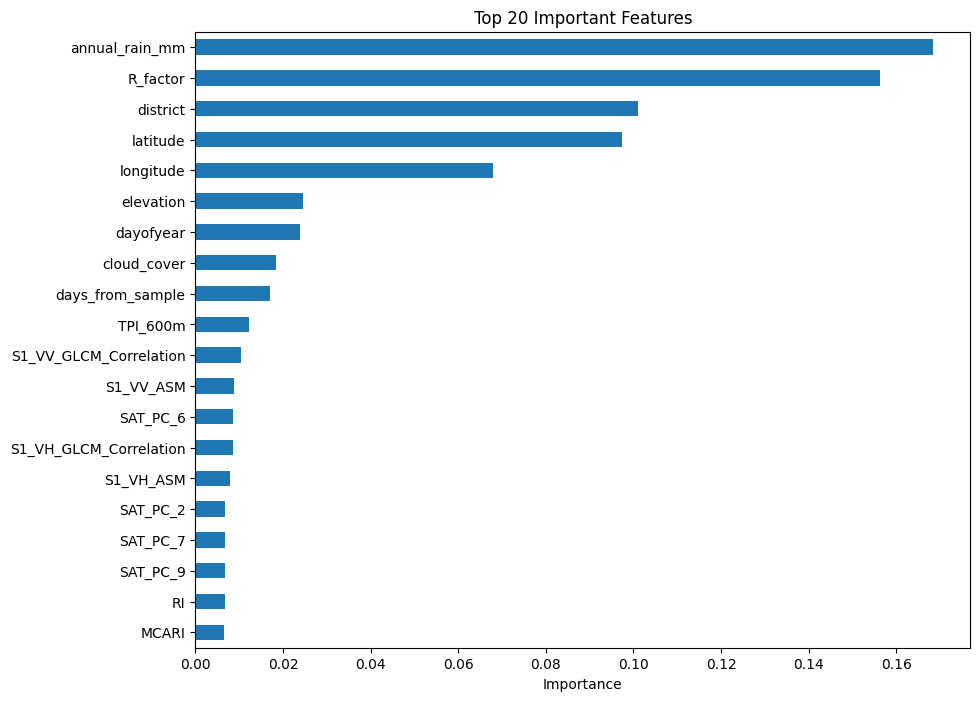

In [34]:
top20 = importance.sort_values(
    ascending=False
).head(20)

plt.figure(
    figsize=(10,8)
)

top20.sort_values().plot(
    kind='barh'
)

plt.xlabel(
    "Importance"
)

plt.title(
    "Top 20 Important Features"
)

plt.show()

In [35]:
print(
    importance.head(20)
)

annual_rain_mm            0.168468
R_factor                  0.156229
district                  0.101052
latitude                  0.097459
longitude                 0.067855
elevation                 0.024667
dayofyear                 0.023998
cloud_cover               0.018449
days_from_sample          0.016966
TPI_600m                  0.012325
S1_VV_GLCM_Correlation    0.010442
S1_VV_ASM                 0.008935
SAT_PC_6                  0.008624
S1_VH_GLCM_Correlation    0.008544
S1_VH_ASM                 0.007936
SAT_PC_2                  0.006866
SAT_PC_7                  0.006799
SAT_PC_9                  0.006746
RI                        0.006746
MCARI                     0.006523
dtype: float64


# Spatial CV 

In [36]:
from sklearn.cluster import KMeans

coords = df[
    ['latitude','longitude']
]

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

spatial_groups = kmeans.fit_predict(
    coords
)

In [37]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(
    n_splits=5
)

In [38]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

r2_scores = []

rmse_scores = []

for train_idx, test_idx in gkf.split(
    X_final,
    y,
    groups=spatial_groups
):

    X_train = X_final.iloc[
        train_idx
    ]

    X_test = X_final.iloc[
        test_idx
    ]

    y_train = y.iloc[
        train_idx
    ]

    y_test = y.iloc[
        test_idx
    ]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    r2_scores.append(

        r2_score(
            y_test,
            pred
        )
    )

    rmse_scores.append(

        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )
    )

In [39]:
print(
    "Spatial CV R2:",
    np.mean(
        r2_scores
    )
)

print(
    "Spatial CV RMSE:",
    np.mean(
        rmse_scores
    )
)

print(
    "Fold R2:",
    r2_scores
)

Spatial CV R2: -0.3408736616869364
Spatial CV RMSE: 0.37171332724375367
Fold R2: [0.3618340223248181, 0.16643187124194192, -0.3233278514642941, 0.13879605250710048, -2.0481024030442483]


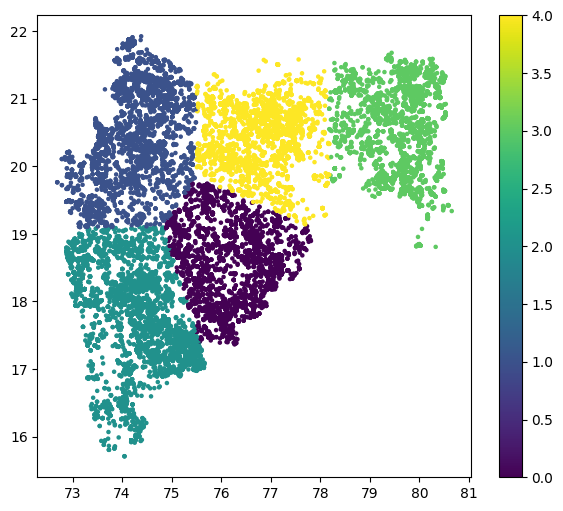

In [40]:
plt.figure(
    figsize=(7,6)
)

plt.scatter(

    df['longitude'],

    df['latitude'],

    c=spatial_groups,

    s=5
)

plt.colorbar()

plt.show()